Importing Necessary Local Files and Wrapper Variables

In [1]:
from H_prep import *
from H_eval import * 
from logistic_regression import * 
from random_forest import * 
from SVM import * 
from EDA import * 

DISPLAY_GRAPHS=True

/home/takeshi-stormer/STAT-587-Final-Project/Project/Models/EDA.py:92: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, p, 'r', lw=2, label=f'Normal Dist. ($\mu={mu:.5f}, \sigma={s:.5f}$)')
/home/takeshi-stormer/STAT-587-Final-Project/Project/Models/EDA.py:92: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, p, 'r', lw=2, label=f'Normal Dist. ($\mu={mu:.5f}, \sigma={s:.5f}$)')


Creating Necessary Variables for EDA

In [2]:
X, y=import_data(testing=True) # Imports only 2 years worth of data for EDA purposes
lookup_df = pd.read_csv(cwd / "Project" / "Data" / "stock_lookup_table.csv")
sector_map=lookup_df.set_index('Ticker')['Sector'].to_dict()

DATA=import_data() # Imports all data over the 8 years for other EDA purposes.
DATA[0].dropna(how='any', axis=0, inplace=True)

------- Downloading Data
Finished Downloading Data -------
Initial shape: 501 rows, 2520 columns.
------- Cleaning data
Finished Cleaning Data -------
Current shape: 501 rows, 2500 columns.
Created Percent Changes.
Created Target (Regression).
Created Day of Week.
Finished Importing Data -------
------- Downloading Data
Finished Downloading Data -------
Initial shape: 2010 rows, 2520 columns.
------- Cleaning data
Finished Cleaning Data -------
Current shape: 2010 rows, 2390 columns.
Created Percent Changes.
Created Target (Regression).
Created Day of Week.
Finished Importing Data -------


Displaying S&P 500 Values over 8 years.

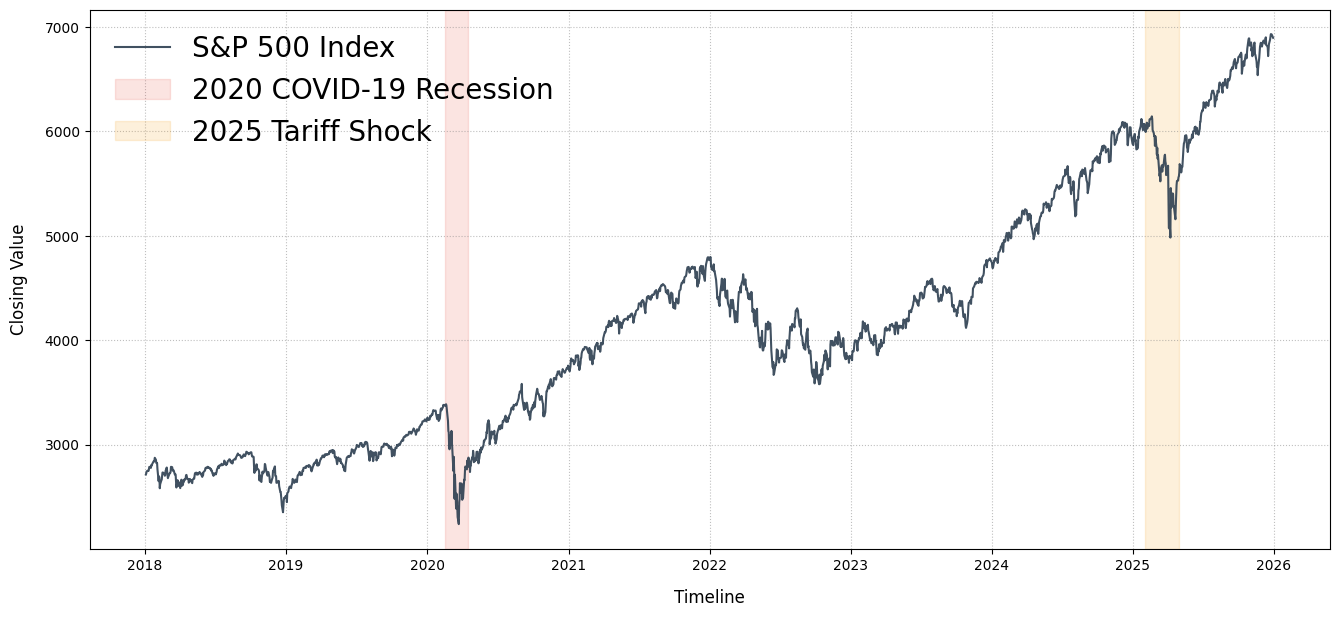

In [3]:
if DISPLAY_GRAPHS:
    display_SP500_index_values(DATA)

Displaying S&P 500 Raw Data Values sample.

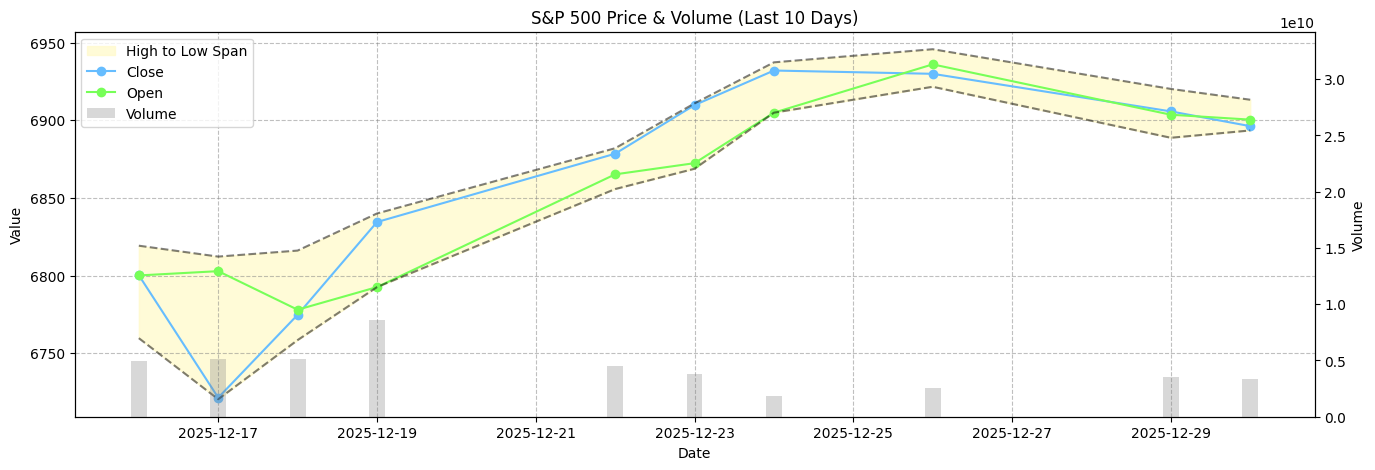

In [4]:
if DISPLAY_GRAPHS:
    display_SP500_raw_feature_values(DATA)

Displaying nonstationary and stationary raw closing price to closing percent change respectively.

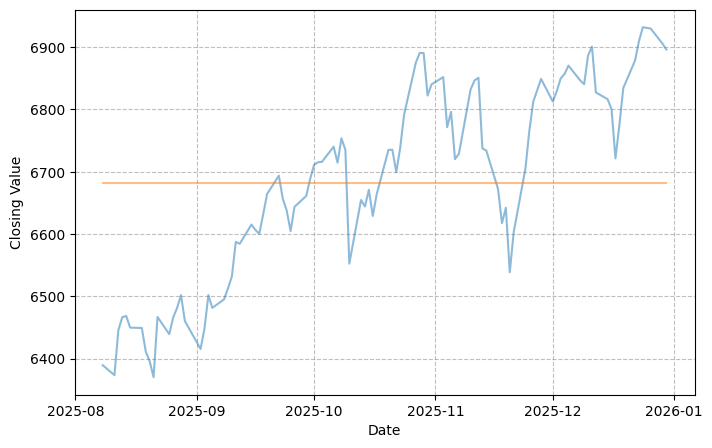

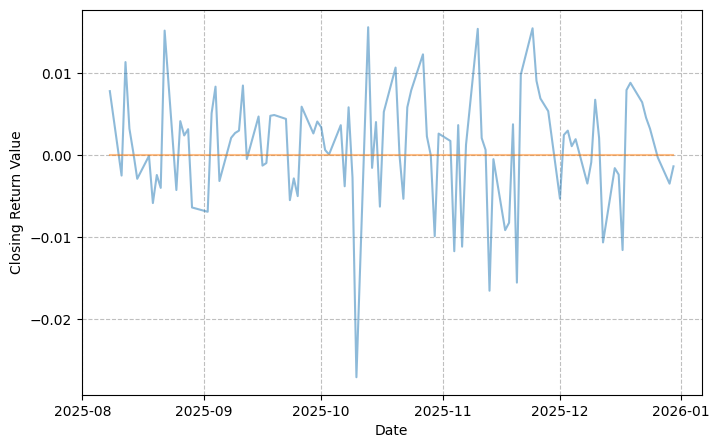

In [5]:
if DISPLAY_GRAPHS:
    display_nonstationary_metric(DATA)
    display_stationary_metric(DATA)

Displaying SP500 returns histogram.

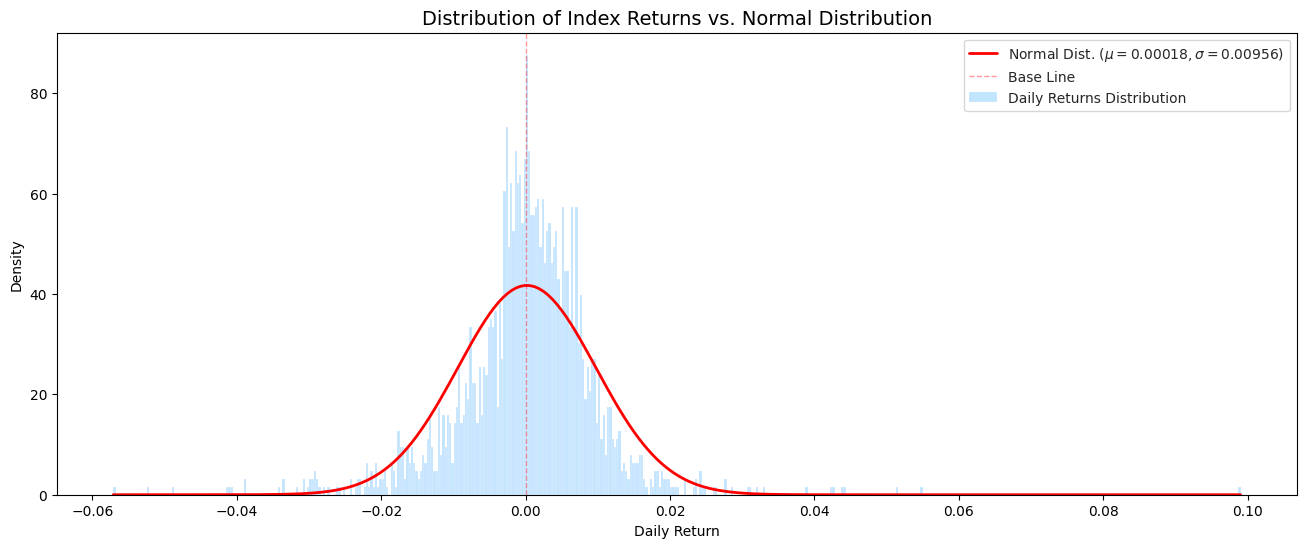

In [6]:
if DISPLAY_GRAPHS:
    display_SP500_return_histogram(DATA)

Displaying classification counts.

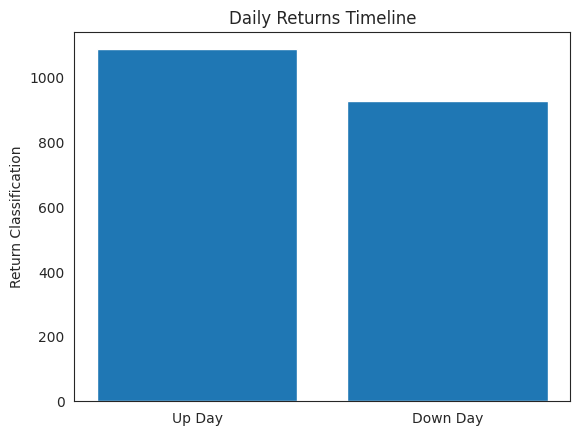

In [7]:
if DISPLAY_GRAPHS:
    display_classification_counts(DATA)

Displaying correlation heatmaps.

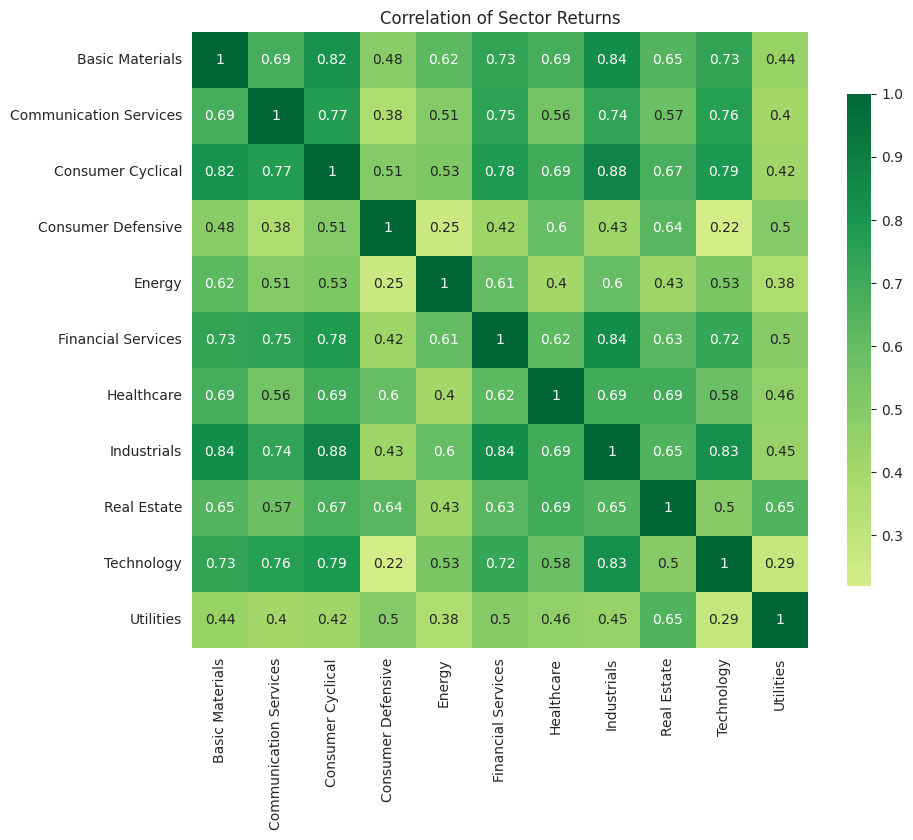

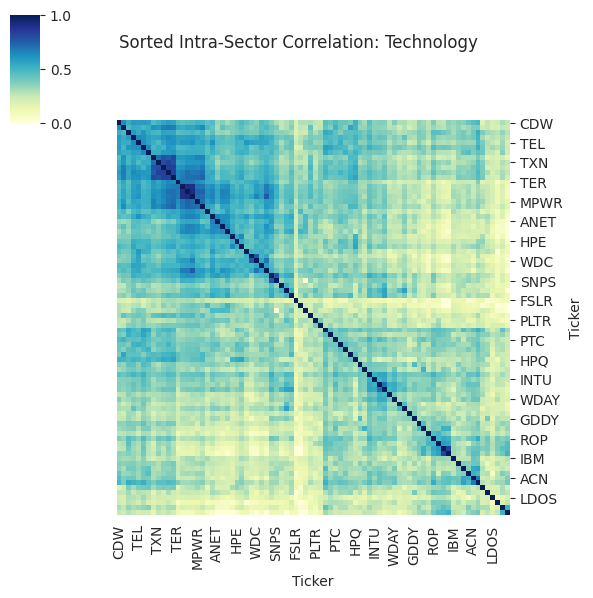

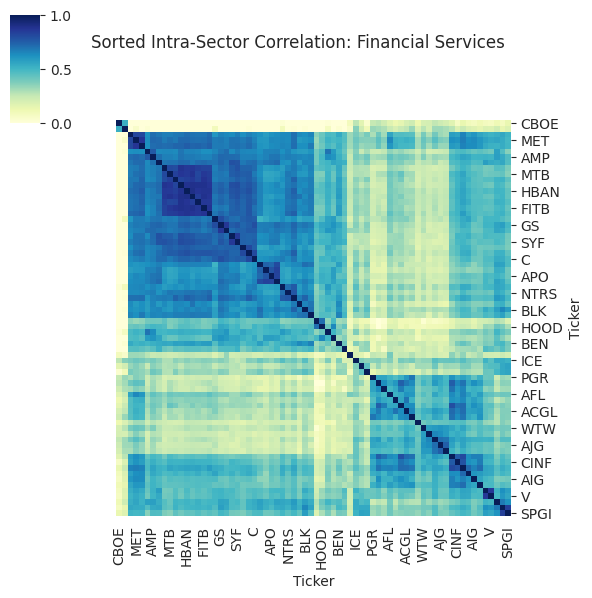

In [8]:
if DISPLAY_GRAPHS:
    plot_sector_correlation(X, y) # If sector_name is left empty, it prints out correlations between all sectors.
    plot_sector_correlation(X, y, sector_name="Technology")
    plot_sector_correlation(X, y, sector_name="Financial Services")

# Viable sector names include:
# 'Consumer Defensive', 'Technology', 'Communication Services', 'Financial Services', 'Energy', 'Utilities', 
# 'Industrials', 'Healthcare', 'Consumer Cyclical', 'Basic Materials', and 'Real Estate'

Displaying sector volatility and returns.

------- Generating Necessary Features
Created Lag.
Created Rolling Volatility (Scaled) and Rolling Z-Score.
Created Max/Min Channel Positions/
Created Open Metrics Forward Lag.
Cleaned up Unnecessary Columns.
Created Target (Classification)
Cleaned up remaining/resulting NA values.
Predictors, and Target (Regression) successfully split.
Finished Generating Features -------
Final shape (X): 473 rows, 6995 columns.
Final shape (y_regression): 473 rows, 1 columns.


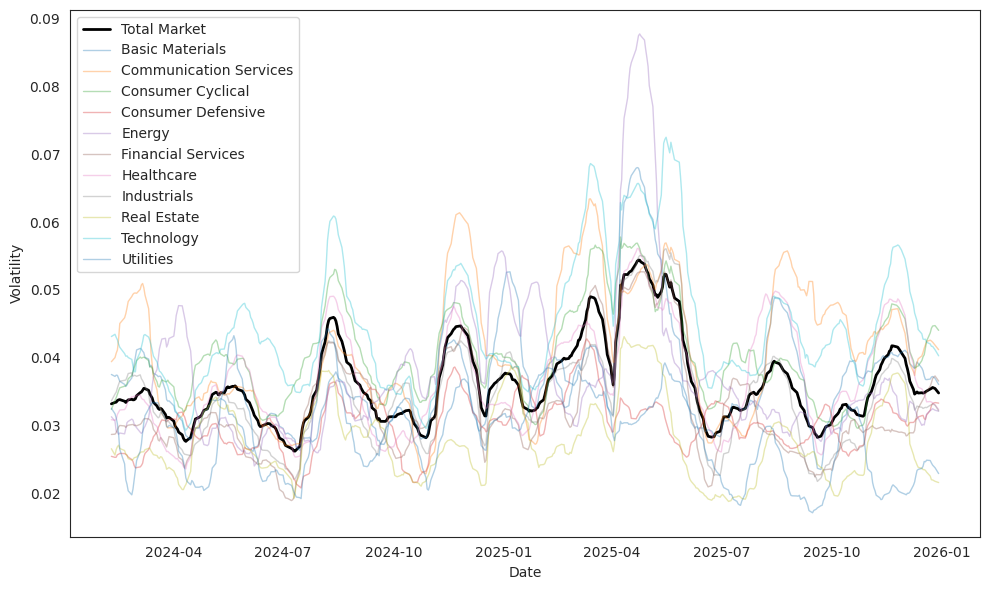

------- Generating Necessary Features
Created Target (Classification)
Cleaned up remaining/resulting NA values.
Predictors, and Target (Regression) successfully split.
Finished Generating Features -------
Final shape (X): 499 rows, 4497 columns.
Final shape (y_regression): 499 rows, 1 columns.


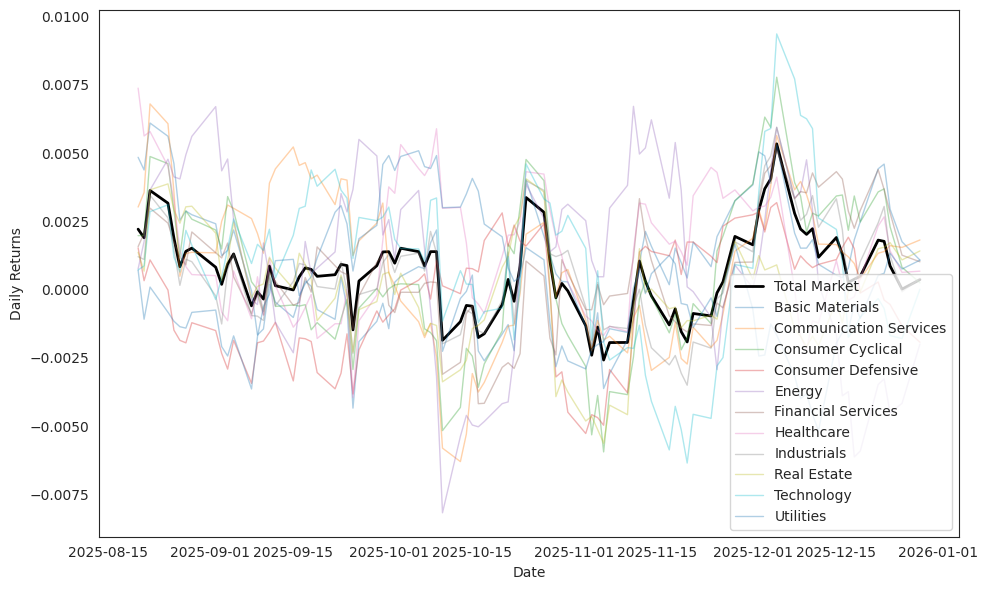

In [9]:
if DISPLAY_GRAPHS:
    display_volatility(X, y)
    display_daily_returns(X, y)

Setting up Necessary Variables for Model Implementation

In [10]:
DATA=import_data() # Redundant since the prior DATA variable wasn't modified, but still to be safe.
FIND_OPTIMAL=False # Set to False it otherwise it increases runtime and the optimal values have already been found and saved.

------- Downloading Data
Finished Downloading Data -------
Initial shape: 2010 rows, 2520 columns.
------- Cleaning data
Finished Cleaning Data -------
Current shape: 2010 rows, 2390 columns.
Created Percent Changes.
Created Target (Regression).
Created Day of Week.
Finished Importing Data -------


Running the Logistic Regression Model

------- Generating Necessary Features
Created Lag.
Created Rolling Volatility (Scaled) and Rolling Z-Score.
Created Max/Min Channel Positions/
Created Open Metrics Forward Lag.
Cleaned up Unnecessary Columns.
Created Target (Classification)
Cleaned up remaining/resulting NA values.
---REDUCE---: Grouped Features by Sector Averages.
Current shape: 1992 rows, 154 columns.
---REDUCE---: (corr_level=2) Dropped 21 highly correlated feature columns.
Predictors, and Target (Regression) successfully split.
Finished Generating Features -------
Final shape (X): 1992 rows, 133 columns.
Final shape (y_regression): 1992 rows, 1 columns.
Rolling Window Backtest over 44 iterations.


/home/takeshi-stormer/STAT-587-Final-Project/Project/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


22.73% complete. Current iteration: 10, True iteration: 361
45.45% complete. Current iteration: 20, True iteration: 761
68.18% complete. Current iteration: 30, True iteration: 1161
90.91% complete. Current iteration: 40, True iteration: 1561
Average Rolling Accuracy (train) (rwb): 0.5057 (±0.0717)
Average Rolling Accuracy (test)  (rwb): 0.4944 (±0.0998)


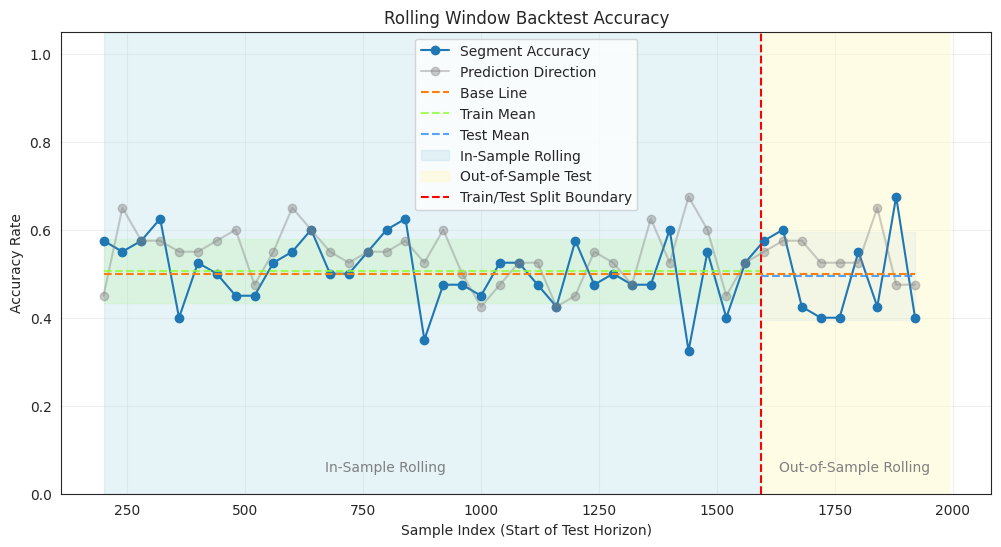

--- Model Report ---
Avg CV Train Accuracy:          0.6897 (±0.0783)
Avg CV Validation Accuracy:  0.5292 (±0.0592)
Avg CV Validation Precision: 0.5606
Avg CV Validation Recall:    0.5415
Final Hold-out (Test) Score (Accuracy): 0.5163
Positive Prediction Rate (Test):        0.7444
True Up Rate (Test):   0.5410
Up Precision (Test):   0.5390
Up Edge Rate (Test):   -0.0020
True Down Rate (Test): 0.4590
Down Precision (Test): 0.4510
Down Edge Rate (Test): -0.0080
             Predicted Down  Predicted Up
Actual Down              46           137
Actual Up                56           160
Utility Score -0.1717


In [11]:
run_logistic_regression(DATA, FIND_OPTIMAL, DISPLAY_GRAPHS)

Running Random Forest Classification Model

------- Generating Necessary Features
Created Lag.
Created Rolling Volatility (Scaled) and Rolling Z-Score.
Created Max/Min Channel Positions/
Created Open Metrics Forward Lag.
Cleaned up Unnecessary Columns.
Created Target (Classification)
Cleaned up remaining/resulting NA values.
---REDUCE---: Grouped Features by Sector Averages.
Current shape: 1982 rows, 220 columns.
---REDUCE---: (corr_level=2) Dropped 5 highly correlated feature columns.
Predictors, and Target (Regression) successfully split.
Finished Generating Features -------
Final shape (X): 1982 rows, 215 columns.
Final shape (y_regression): 1982 rows, 1 columns.


------- LASSO RF Model -------
Rolling Window Backtest over 44 iterations.
22.73% complete. Current iteration: 10, True iteration: 361
45.45% complete. Current iteration: 20, True iteration: 761
68.18% complete. Current iteration: 30, True iteration: 1161
90.91% complete. Current iteration: 40, True iteration: 1561
Average Rolling Accuracy (train) (rwb): 0.4871 (±0

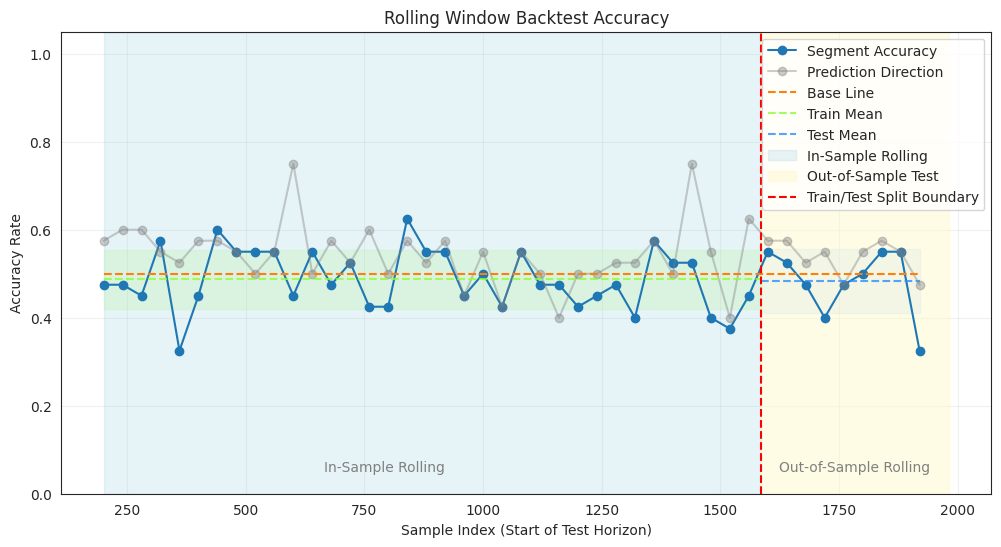

--- Model Report ---
Avg CV Train Accuracy:          0.9413 (±0.0485)
Avg CV Validation Accuracy:  0.5432 (±0.0223)
Avg CV Validation Precision: 0.5779
Avg CV Validation Recall:    0.5915
Final Hold-out (Test) Score (Accuracy): 0.5063
Positive Prediction Rate (Test):        0.5290
True Up Rate (Test):   0.5440
Up Precision (Test):   0.5480
Up Edge Rate (Test):   0.0040
True Down Rate (Test): 0.4560
Down Precision (Test): 0.4600
Down Edge Rate (Test): 0.0040
             Predicted Down  Predicted Up
Actual Down              86            95
Actual Up               101           115
Utility Score -0.1105
Downloaded results to /home/takeshi-stormer/STAT-587-Final-Project/Project/Models/results/results.csv


In [12]:
run_random_forest_classification(DATA, FIND_OPTIMAL, DISPLAY_GRAPHS)

Running Support Vector Machine Model

------- Generating Necessary Features
Created Lag.
Created Rolling Volatility (Scaled) and Rolling Z-Score.
Created Max/Min Channel Positions/
Created Open Metrics Forward Lag.
Cleaned up Unnecessary Columns.
Created Target (Classification)
Cleaned up remaining/resulting NA values.
---REDUCE---: Grouped Features by Sector Averages.
Current shape: 1985 rows, 154 columns.
---REDUCE---: (corr_level=2) Dropped 5 highly correlated feature columns.
Predictors, and Target (Regression) successfully split.
Finished Generating Features -------
Final shape (X): 1985 rows, 149 columns.
Final shape (y_regression): 1985 rows, 1 columns.


------- RBF SVM Model -------
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Rolling Window Backtest over 44 iterations.
22.73% complete. Current iteration: 10, True iteration: 361
45.45% complete. Current iteration: 20, True iteration: 761
68.18% complete. Current iteration: 30, True iteration: 1161
90.91% complete. Current iteration: 40, True iterat

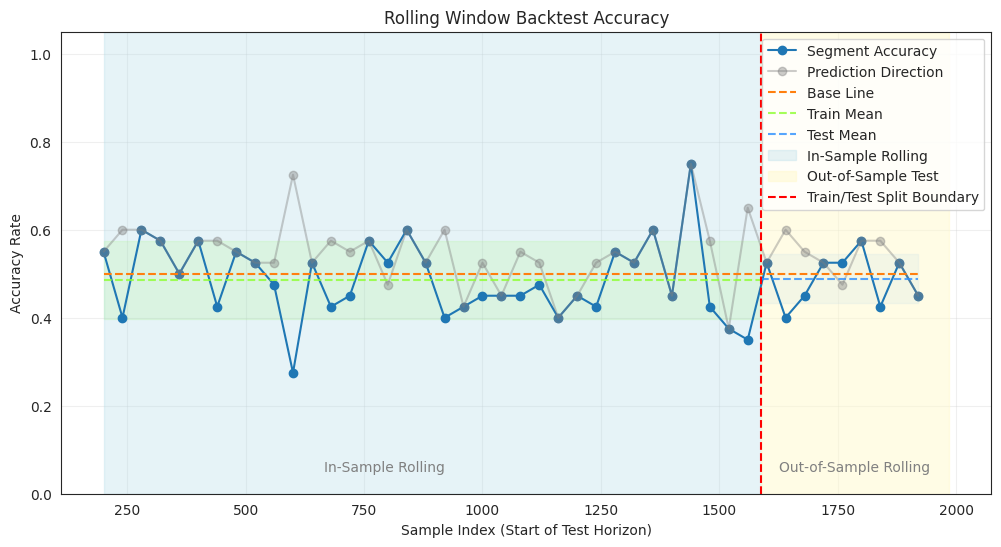

--- Model Report ---
Avg CV Train Accuracy:          0.5403 (±0.0353)
Avg CV Validation Accuracy:  0.5402 (±0.0190)
Avg CV Validation Precision: 0.591
Avg CV Validation Recall:    0.7111
Final Hold-out (Test) Score (Accuracy): 0.5088
Positive Prediction Rate (Test):        0.4458
True Up Rate (Test):   0.5440
Up Precision (Test):   0.5590
Up Edge Rate (Test):   0.0150
True Down Rate (Test): 0.4560
Down Precision (Test): 0.4680
Down Edge Rate (Test): 0.0120
             Predicted Down  Predicted Up
Actual Down             103            78
Actual Up               117            99
Utility Score -0.05715
Downloaded results to /home/takeshi-stormer/STAT-587-Final-Project/Project/Models/results/results.csv


In [13]:
run_SVM_model(DATA, FIND_OPTIMAL, DISPLAY_GRAPHS)